# 黒良さんの天気図作成を試してみました。
500hPa面天気図作成１と２をJupyternotebookに貼り付けて、grib2データは気象業務支援センターのサンプルをダウンロードして試しました。
コードを理解していないので結構手こずりましたが、ChatGPTに聞きながら何とかなりました。
ChatGPTはgrib2データのことも理解（といっていいのか？）して、適切に教えてくれます。
grib2データ
https://www.jmbsc.or.jp/jp/online/c-onlineGsample.html#sample413
黒良さんNote
https://note.com/rkurora/n/n200fdd8f1aa1?sub_rt=share_pw

手間取ったところを書きます。
pygribのインポートで以下のエラーが出て、
 
ImportError: dlopen(...libcurl.4.dylib...): Symbol not found: _SSL_get0_group_name
Expected in: ...libssl.3.dylib
 
原因は「pygrib（や pyproj）は内部で Cライブラリ（libcurl, libssl, libcrypto など）に依存していて、python3.11が合っていない」ということでpythonのバージョンを3.10にしたpython仮想環境を作って、その環境でpythonを実行して解決しました。
エラー対応は全てchatgptに聞いて対応しています。

import os 以下は上原の環境によるもので、削除して、必要なら各自で修正してください。
データ格納フォルダ名も要修正

# 著作権があるはずなので、どこにも公開しないでください。

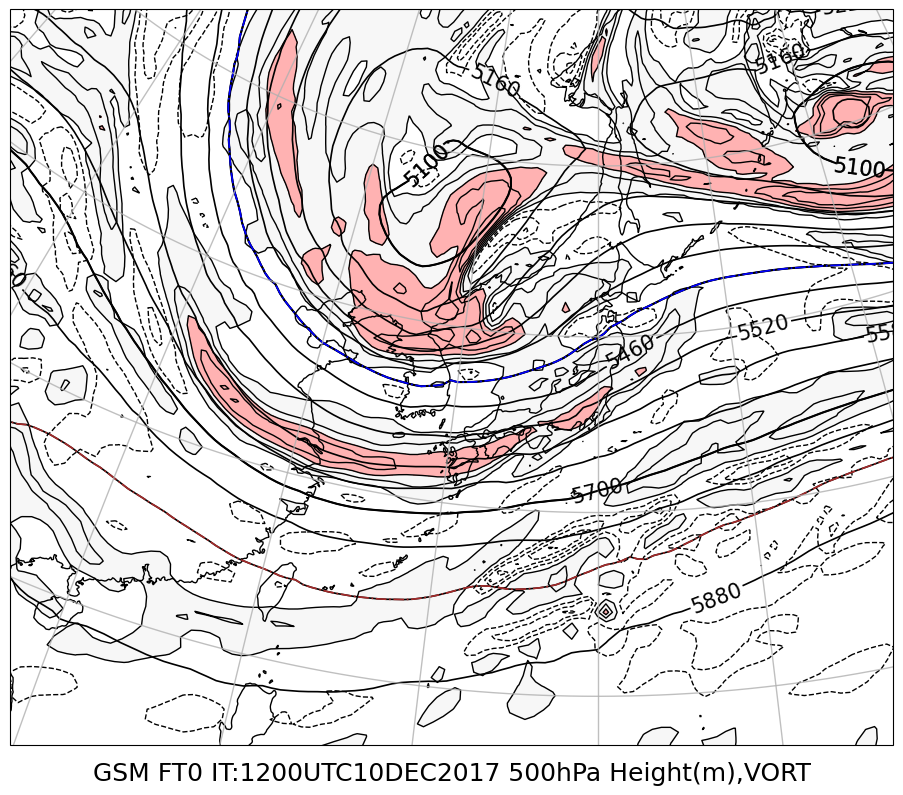

In [1]:
import os
os.environ['PROJ_LIB'] = '/opt/anaconda3/envs/met_env_310/share/proj'  # ★この行はimportの前！

from pyproj import datadir, CRS
datadir.set_data_dir(os.environ['PROJ_LIB'])  # ← 明示的にpyprojにパスを渡す！

import math
import pygrib
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import matplotlib.path as mpath
import cartopy.crs as ccrs
import datetime
import sys
#                                                                                                                                   
import metpy.calc as mpcalc
from metpy.units import units
#from scipy.ndimage.filters import maximum_filter, minimum_filter　#今後使えなくなるとChatgptに言われたので修正
from scipy.ndimage import maximum_filter, minimum_filter  # ← 修正済み
#                                                                                                                                   
import argparse

# GSMの読み込む初期値の年月日時をUTCで与えます。
i_year =2017
i_month = 12
i_day = 10
i_hourZ = 12
#
# 予想時間を与える。この値は注意が必要です。下3桁目が日数、下２桁で時間で与えます。
#  初期値なら0、18時間後なら18、24時間後なら100、36時間後なら112となります。
i_ft = 0
#
# 読み込む気圧面の気圧を与えます。ここでは500hPaと指定します。
tagHp = 500
#
# データの格納先フォルダー名
data_fld="./data_gsm/"
####################################################
#
# 読み込むGRIB2形式GSMのファイル名
gsm_fn_t="Z__C_RJTD_{0:4d}{1:02d}{2:02d}{3:02d}0000_GSM_GPV_Rgl_FD{4:04d}_grib2.bin" #全球モデル
#gsm_fn_t="Z__C_RJTD_20230601000000_GSM_GPV_Rjp_Gll0p1deg_L-pall_FD0403-0500_grib2.bin"
gr_fn= gsm_fn_t.format(i_year,i_month,i_day,i_hourZ,i_ft)
#
# データOpen
grbs = pygrib.open(data_fld + gr_fn)
#
# データ取得                                                                                                                       
grbHt = grbs(shortName="gh",typeOfLevel='isobaricInhPa',level=tagHp)[0]
grbWu = grbs(shortName="u",typeOfLevel='isobaricInhPa',level=tagHp)[0]
grbWv = grbs(shortName="v",typeOfLevel='isobaricInhPa',level=tagHp)[0]
#
# データClose
grbs.close()

## GPVの切り出し領域の指定：(lonW,latS)-(lonE,latN)の矩形                                                                                                      
latS=-20
latN=80
lonW=70
lonE=190
## データ切り出し                                                                                                                   
valHt, latHt, lonHt = grbHt.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
valWu, latWu, lonWu = grbWu.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
valWv, latWv, lonWv = grbWv.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)

## 渦度などの算出のためにxarrayデータセットを作成                                                                                   
ds = xr.Dataset(
   {
       "Geopotential_height": (["lat", "lon"], valHt),                                                                        
       "u_wind": (["lat", "lon"], valWu),
       "v_wind": (["lat", "lon"], valWv),
   },
   coords={
       "level": [tagHp],
       "lat": latHt[:,0],
       "lon": lonHt[0,:],
       "time": [grbHt.validDate],
   },
)
# 単位も入力する
ds['Geopotential_height'].attrs['units'] = 'm'
ds['u_wind'].attrs['units']='m/s'
ds['v_wind'].attrs['units']='m/s'
ds['level'].attrs['units'] = 'hPa'
ds['lat'].attrs['units'] = 'degrees_north'
ds['lon'].attrs['units'] = 'degrees_east'

## 算出                                                                                                                             
# 相対渦度                                                                                                                          
ds['vorticity'] = mpcalc.vorticity(ds['u_wind'],ds['v_wind'])

## 表示用の指定
# 図法指定　気象庁の数値予報資料と同じ図法に設定                                                                                
proj = ccrs.Stereographic(central_latitude=60, central_longitude=140)
latlon_proj = ccrs.PlateCarree() # 緯度経度の処理用に正距円筒図法も使う  
#
# 地図の描画範囲指定
areaAry = [108, 156, 17, 55]  # 極東
#areaAry = [115, 151, 20, 50]  # 日本付近
#
# 等値線の間隔を指定
levels_ht =np.arange(4800, 6000,  60)  # 高度を60m間隔で実線                       
levels_ht2=np.arange(4800, 6000, 300)  # 高度を300m間隔で太線
levels_vr =np.arange(-0.0002, 0.0002, 0.00004)  # 渦度4e-5毎に等値線
#
# 渦度のハッチの指定
levels_h_vr = [0.0, 0.00008, 1.0]    # 0.0以上で 灰色(0.9), 8e-5以上で赤
colors_h_vr = ['0.9','red']
alpha_h_vr = 0.3                     # 透過率を指定
#
# 緯度・経度線の指定
dlon,dlat=10,10   # 10度ごとに
#
## タイトル文字列用
# 予想時間を得る
ft_hours=int(i_ft/100) * 24 + int(i_ft%100)
# 初期時刻の文字列
dt_i = grbHt.analDate
dt_str = (dt_i.strftime("%H00UTC%d%b%Y")).upper()
dt_str2 = dt_i.strftime("%Y%m%d%H")

## 図のSIZE指定inch                                                                        
fig = plt.figure(figsize=(10,8))
#
## 余白設定                                                                                
plt.subplots_adjust(left=0, right=1, bottom=0.06, top=0.98)
#                 
## 作図開始                                                                                    
ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_extent(areaAry, latlon_proj)

# 500hPa 相対渦度のハッチ 0.0以上:着色  0.8*10**-4以上:赤                                  
cn_relv_hatch2 = ax.contourf(ds['lon'], ds['lat'], ds['vorticity'],
       levels_h_vr, colors=colors_h_vr,
       alpha=alpha_h_vr, transform=latlon_proj)
# 5000hPa 相対渦度 実線 0.00004毎 負は破線                                                 
cn_relv = ax.contour(ds['lon'], ds['lat'], ds['vorticity'],
       levels_vr, colors='black', linewidths=1.0, transform=latlon_proj)
# 500hPa  等高度線 実線 step1:60m毎                                                                                                          
cn_hgt = ax.contour(ds['lon'], ds['lat'], ds['Geopotential_height'],
                   colors='black',
                   linewidths=1.2, levels=levels_ht, transform=latlon_proj )
ax.clabel(cn_hgt, levels_ht, fontsize=15, inline=True, inline_spacing=5,
         fmt='%i', rightside_up=True)
# 500hPa 等高度線 太線 step1:300m毎                                                        
cn_hgt2= ax.contour(ds['lon'], ds['lat'], ds['Geopotential_height'],
                   colors='black',
                   linewidths=1.5, levels=levels_ht2, transform=latlon_proj)
ax.clabel(cn_hgt2, fontsize=15, inline=True, inline_spacing=0,
         fmt='%i', rightside_up=True)
# 500hPa 5820gpm高度線 茶色                                                         
cn5820 = ax.contour(ds['lon'], ds['lat'], ds['Geopotential_height'],
                   colors='brown',linestyles='dashdot',
                   linewidths=1.2, levels=[5820], transform=latlon_proj )
# 500hPa 5400gpm高度線 青色                                                            
cn5400 = ax.contour(ds['lon'], ds['lat'], ds['Geopotential_height'],
                   colors='blue',linestyles='dashdot',
                   linewidths=1.2, levels=[5400], transform=latlon_proj )

## 海岸線                                                                                                                               
ax.coastlines(resolution='50m',)
## グリッド                                                                   
xticks=np.arange(0,360.1,dlon)
yticks=np.arange(-90,90.1,dlat)
gl = ax.gridlines(crs=ccrs.PlateCarree()
        , draw_labels=False
        , linewidth=1, alpha=0.8)
gl.xlocator = mticker.FixedLocator(xticks)
gl.ylocator = mticker.FixedLocator(yticks)
#                                                                                          
## Title                                                                        
fig.text(0.5,0.01,
        "GSM FT{0:d} IT:".format(ft_hours)+dt_str+" 500hPa Height(m),VORT" ,
        ha='center',va='bottom', size=18)
# 出力
plt.show()